# Desafio da Semana 2

**PES310 — Modelagem e Inferência Estatística**

## 1. Enunciado

Na aula da Semana 1 foi usada a base de dados da loja “GT Auto”, ela foi incrementada e agora contém 28 carros, sendo alguns de motor aspirado e outros de motor turbo. As seguintes informações estão incluídas na base de dados, na qual estão a informação que representa e o nome com que a variável foi armazenada (reveja a Videoaula 6 se necessário):

- Marca/Modelo/Ano do carro: `brand/model/year`.
- Capacidade volumétrica (cc) ou volume de deslocamento do motor: `cap_vol`.
- Consumo de combustível (km/l): `consumo`.
- Potência (cv): `power`.
- Peso (kg): `weight`.
- 0-100 (s), tempo que o carro demora para atingir 100 m: `cem`.
- Número de cilindros: `nu_cy`.
- Tipo de motor, aspirado (0) ou turbo (1): `Etype`.

Algumas dessas variáveis foram comparadas entre si para verificar o coeficiente de correlação entre elas, na sequência, realize as seguintes atividades para poder facilitar o treinamento dos novos vendedores da “GT Auto”:

- Escolha uma variável entre todas as apresentadas e faça diagramas de dispersão para verificar a relação dela com as outras variáveis. Pense qual é o tipo de correlação para esses dados.

- Calcule o coeficiente de correlação e verifique se confere com o que você pensou observando os diagramas.
Observe a tendência do coeficiente de correlação da variável escolhida com as outras seis e comente as suas observações no Fórum Temático.

- De acordo com as suas observações, classifique seu conjunto de dados, em dois ou três grupos (por exemplo, na aula 3 foi adotado como critério de classificação o tipo de motor).

- Crie outros diagramas de dispersão com os dados reclassificados e explique as suas ideias para poder ajudar no treinamento dos novos atendentes da “GT Auto”.


## 2. Objetivo da análise

Investigar como a potência dos veículos (`power`) se relaciona com suas demais
características e verificar se essas relações mudam quando os carros são
classificados em diferentes grupos.

Inicialmente, os dados serão analisados em conjunto. Posteriormente, serão
separados de acordo com uma característica relevante dos veículos.

## 3. Preparação do ambiente

In [244]:
import numpy as np
import pandas as pd
# import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator

from IPython.display import display, Math

In [245]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [246]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
MAT_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'kirsten.mplstyle'
SEMANA_DIR = MAT_DIR / 'semana-02'
DATA_DIR = SEMANA_DIR / 'dados'

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", MAT_DIR)
print("EXP_DIR:", SEMANA_DIR)
print("DATA_DIR:", DATA_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\univesp-data-science
EXP_DIR: D:\Documents\GitHub\univesp-data-science\modelagem-inferencia-estatistica
EXP_DIR: D:\Documents\GitHub\univesp-data-science\modelagem-inferencia-estatistica\semana-02
DATA_DIR: D:\Documents\GitHub\univesp-data-science\modelagem-inferencia-estatistica\semana-02\dados


C:\Users\petru\AppData\Local\Temp\ipykernel_25004\3361463850.py:15: MatplotlibDeprecationWarning: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  plt.style.use(STYLE_DIR)  # custom matplotlib style for plots
C:\Users\petru\AppData\Local\Temp\ipykernel_25004\3361463850.py:15: MatplotlibDeprecationWarning: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  plt.style.use(STYLE_DIR)  # custom matplotlib style for plots


## 4. Carregamento e inspeção dos dados

In [247]:
df = pd.read_csv(DATA_DIR / "s2_carst.csv")

In [248]:
display(df.head())

print(f"Dimensões: {df.shape}")
display(df.dtypes)
display(df.isna().sum())
display(df.duplicated().value_counts())

print(df.columns.tolist())

,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
0,Gurgel BR800 0.8 1991,792,12.0,33,650,34.4,2,0
1,FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
2,Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
3,FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
4,VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0


Dimensões: (28, 8)


brand/model/year        str
cap_vol               int64
consumo             float64
power                 int64
weight                int64
cemm                float64
nu_cy                 int64
Etype                 int64
dtype: object

brand/model/year    0
cap_vol             0
consumo             0
power               0
weight              0
cemm                0
nu_cy               0
Etype               0
dtype: int64

False    28
Name: count, dtype: int64

['brand/model/year', 'cap_vol', 'consumo', 'power', 'weight', 'cemm', 'nu_cy', 'Etype']


## 5. Resumo descritivo

In [249]:
variaveis_numericas = [
    "cap_vol",
    "consumo",
    "power",
    "weight",
    "cemm",
    "nu_cy",
    "Etype",
]

df[variaveis_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
cap_vol,28.0,3003.000000,2043.372847,792.0,1473.250,1998.5,3844.750,7993.0
consumo,28.0,8.096429,3.017171,2.6,6.325,8.6,10.525,12.8
power,28.0,323.607143,307.036774,33.0,141.250,178.5,472.500,1500.0
weight,28.0,1422.785714,332.713686,650.0,1260.750,1409.5,1726.000,1998.0
cemm,28.0,8.542857,6.342124,2.5,4.125,7.7,9.900,34.4
nu_cy,28.0,5.964286,3.371802,2.0,4.000,4.0,6.500,16.0
Etype,28.0,0.500000,0.509175,0.0,0.000,0.5,1.000,1.0


In [250]:
df["Etype"].value_counts().sort_index()

Etype
0    14
1    14
Name: count, dtype: int64

In [251]:
df["nu_cy"].value_counts().sort_index()

nu_cy
2      1
3      3
4     11
6      6
8      3
12     3
16     1
Name: count, dtype: int64

## 6. Estratégia de análise

In [252]:
variavel_central = "power"

comparacoes = [
    "cap_vol",
    "consumo",
    "weight",
    "cemm",
    "nu_cy",
    "Etype",
]

## 7. Capacidade volumétrica e potência

### 7.1 Relação global

Primeiro, avalia-se a associação entre as variáveis no conjunto completo de veículos.

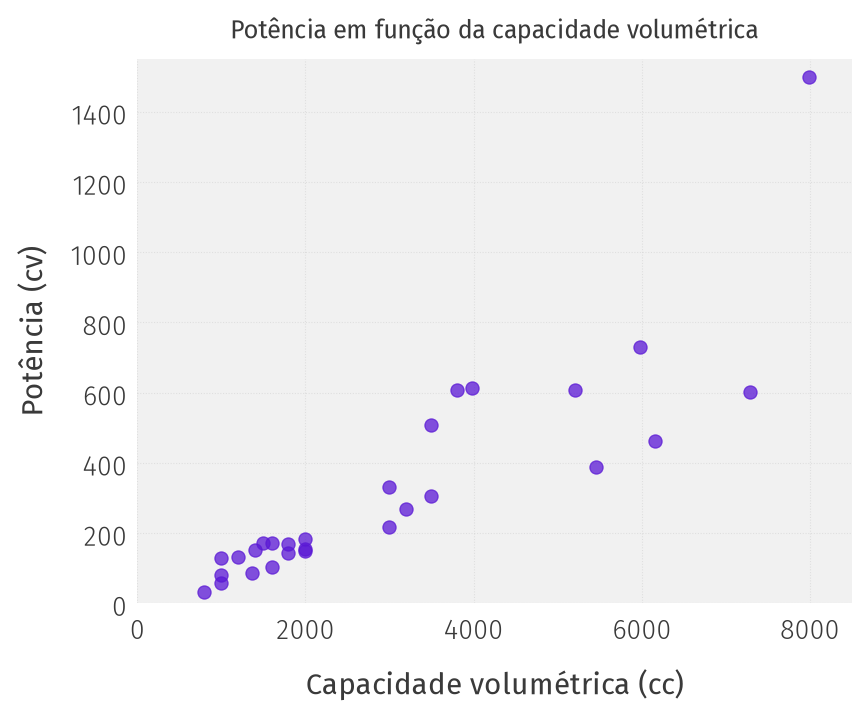

In [253]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title("Potência em função da capacidade volumétrica")
ax.set_xlabel("Capacidade volumétrica (cc)"); ax.set_ylabel("Potência (cv)")
ax.set_xlim([0, 8500]); ax.set_ylim([0, 1550])

ax.scatter(
    df["cap_vol"],
    df["power"],
    s=40,
    alpha=.75,
    # edgecolor="black",
    linewidth=0.6,
    zorder=2
)

ax.grid(alpha=0.5, ls=':', zorder=-1)

plt.tight_layout()

In [254]:
r = df["cap_vol"].corr(df["power"], method="pearson")
print(f"Correlação entre capacidade volumétrica e potência: r = {r:.3f}")

Correlação entre capacidade volumétrica e potência: r = 0.872


Observa-se uma associação positiva entre capacidade volumétrica e potência:
veículos com motores maiores tendem a apresentar maior potência. O coeficiente
de correlação de Pearson foi r = 0,872, indicando uma correlação linear positiva
forte.

Entretanto, a distribuição dos pontos não é perfeitamente homogênea. Existem
possíveis agrupamentos e um veículo com valores muito elevados de capacidade
volumétrica e potência, que pode exercer forte influência sobre o coeficiente.
Além disso, a variabilidade da potência parece aumentar entre os motores de
maior capacidade. Portanto, o valor de r deve ser interpretado em conjunto com
o diagrama de dispersão.

### 7.2 Influência do ponto extremo na correlação global

In [255]:
indice_extremo = df["power"].idxmax()
df_sem_extremo = df.drop(index=indice_extremo)

r_completo = df["cap_vol"].corr(df["power"])
r_sem_extremo = df_sem_extremo["cap_vol"].corr(df_sem_extremo["power"])

print(f"Correlação com todos os carros: r = {r_completo:.3f}")
print(f"Correlação sem o ponto extremo: r = {r_sem_extremo:.3f}")

display(df.loc[[indice_extremo]])

Correlação com todos os carros: r = 0.872
Correlação sem o ponto extremo: r = 0.884


,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
27,Bugatti Chiron 8.0 W16 2016,7993,3.8,1500,1998,2.5,16,1


### 7.3 Classificação por tipo de motor

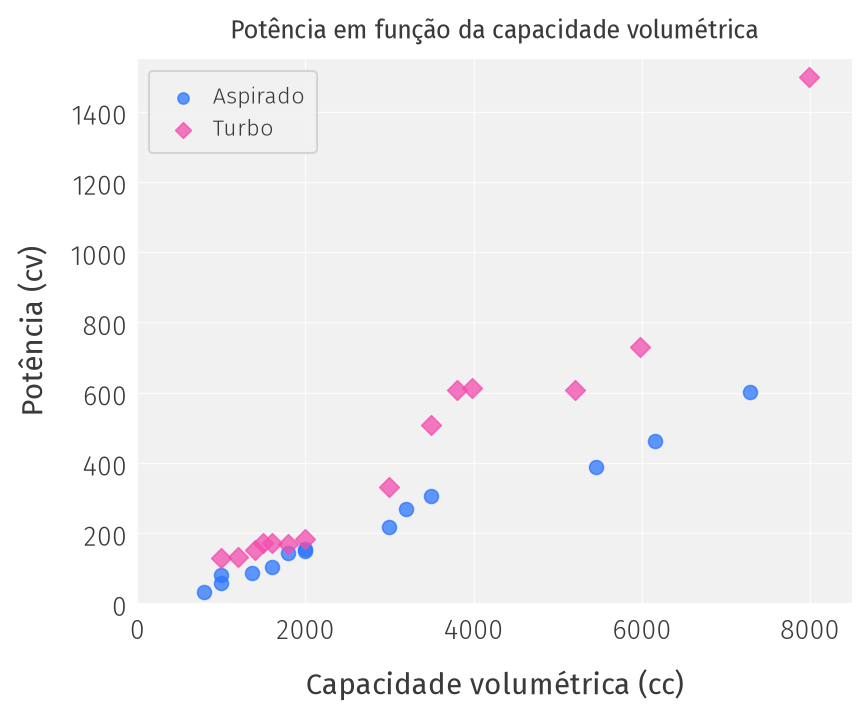

In [256]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title("Potência em função da capacidade volumétrica")
ax.set_xlabel("Capacidade volumétrica (cc)"); ax.set_ylabel("Potência (cv)")
ax.set_xlim([0, 8500]); ax.set_ylim([0, 1550])

estilos_motor = {
    0: {
        "label": "Aspirado",
        # "color": "#494949",
        "color": "#2C76FF",
        "marker": "o",
    },
    1: {
        "label": "Turbo",
        # "color": "#9E9E9E",
        "color": "#F34DAE",
        "marker": "D",
    },
}

for tipo_motor, estilo in estilos_motor.items():
    grupo = df[df["Etype"] == tipo_motor]

    ax.scatter(
        grupo["cap_vol"],
        grupo["power"],
        label=estilo["label"],
        color=estilo["color"],
        marker=estilo["marker"],
        s=45,
        alpha=.75,
        # edgecolor="black",
        linewidth=.75,
        zorder=2
    )

ax.grid(alpha=0.85, color='white', lw=.6, ls='-', zorder=-1)
ax.legend(fontsize=11, frameon=True, loc='upper left')

plt.tight_layout()

A classificação por tipo de motor revelou que os grupos não estão completamente
separados quanto à capacidade volumétrica. Entretanto, para capacidades semelhantes,
os veículos turbo geralmente apresentam maior potência que os aspirados.

A associação positiva entre capacidade volumétrica e potência permanece visualmente
presente nos dois grupos. Entre os veículos turbo, o aumento da potência também parece
mais acentuado, embora essa diferença de inclinação ainda precise ser avaliada
quantitativamente. O veículo com os maiores valores de capacidade volumétrica e
potência pertence ao grupo turbo e pode influenciar fortemente os resultados.

In [257]:
r_global = df["cap_vol"].corr(df["power"])

correlacoes_por_motor = (
    df.groupby("Etype")
      .apply(
          lambda grupo: grupo["cap_vol"].corr(grupo["power"]),
          include_groups=False,
      )
)

print(f"Correlação global: r = {r_global:.3f}")
print(f"Aspirados: r = {correlacoes_por_motor.loc[0]:.3f}")
print(f"Turbos: r = {correlacoes_por_motor.loc[1]:.3f}")

df.groupby("Etype").size().rename({0: "Aspirado", 1: "Turbo"})

Correlação global: r = 0.872
Aspirados: r = 0.992
Turbos: r = 0.961


Etype
Aspirado    14
Turbo       14
dtype: int64

A capacidade volumétrica apresentou correlação positiva forte com a potência
quando todos os veículos foram analisados em conjunto (r = 0,872).

Após a classificação por tipo de motor, a associação tornou-se ainda mais forte:
r = 0,992 para os veículos aspirados e r = 0,961 para os veículos turbo. Os
grupos possuem o mesmo tamanho amostral, com 14 veículos cada.

Esses resultados indicam que a relação entre capacidade volumétrica e potência
é aproximadamente linear dentro de ambos os tipos de motor. A correlação global
mais baixa provavelmente ocorre porque ela combina dois grupos com
características diferentes, uma vez que os veículos turbo tendem a apresentar
maior potência para capacidades volumétricas semelhantes.

Entretanto, os coeficientes de correlação não permitem concluir qual grupo
apresenta o maior aumento de potência por unidade de cilindrada. Para isso,
seria necessário comparar as inclinações das retas ajustadas aos dois grupos.

### 7.4 Ajustes lineares por grupo

As retas principais são ajustadas com todos os veículos de cada grupo.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Capacidade volumétrica (cc)")
ax.set_ylabel("Potência (cv)")
ax.set_xlim([0, 8500])
ax.set_ylim([0, 1600])

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.yaxis.set_major_locator(MultipleLocator(200))
ax.yaxis.set_minor_locator(MultipleLocator(100))

resultados_ajuste = {}

for tipo_motor, estilo in estilos_motor.items():
    grupo = df[df["Etype"] == tipo_motor]

    x = grupo["cap_vol"].to_numpy()
    y = grupo["power"].to_numpy()

    b1, b0 = np.polyfit(x, y, deg=1)

    resultados_ajuste[tipo_motor] = {
        "tipo_motor": estilo["label"],
        "intercepto": b0,
        "inclinacao": b1,
        "cv_por_1000_cc": b1 * 1000,
        "n_ajuste": len(grupo),
    }

    ax.scatter(
        x,
        y,
        label=estilo["label"],
        color=estilo["color"],
        marker=estilo["marker"],
        s=45,
        alpha=.75,
        linewidth=.75,
        zorder=3,
    )

    x_reta = np.linspace(x.min(), x.max(), 100)
    y_reta = b0 + b1 * x_reta

    ax.plot(
        x_reta,
        y_reta,
        color=estilo["color"],
        lw=.75,
        ls=":",
        alpha=.95,
        zorder=2,
    )

ax.grid(
    which="major",
    alpha=.85,
    color="white",
    lw=.6,
    ls="-",
    zorder=-2,
)
ax.grid(
    which="minor",
    alpha=.65,
    color="white",
    lw=.4,
    ls="-",
    zorder=-2,
)
ax.legend(frameon=True, loc="upper left", linewidth=.6)

plt.tight_layout()
plt.show()


In [ ]:

linhas = []

for resultado in resultados_ajuste.values():
    grupo = resultado["tipo_motor"]
    b0 = resultado["intercepto"]
    b1 = resultado["inclinacao"]

    sinal = "+" if b0 >= 0 else "-"

    linhas.append(
        rf"\text{{{grupo}:}}\quad "
        rf"\widehat{{P}} = "
        rf"\left({b1:.4f}\,\,"
        rf"\frac{{\mathrm{{cv}}}}{{\mathrm{{cc}}}}\right)V "
        rf"{sinal} "
        rf"{abs(b0):.2f}\,\mathrm{{cv}}"
    )

equacoes = (
    r"\begin{aligned}"
    + r" \\[6pt] ".join(linhas)
    + r"\end{aligned}"
)

display(Math(equacoes))

display(Math(
    r"[V]=\mathrm{cc},"
    r"\qquad"
    r"[\widehat{P}]=\mathrm{cv}"
))

### 7.5 Análise de sensibilidade do turbo extremo

O veículo permanece na análise principal; sua exclusão abaixo serve apenas para quantificar sua influência sobre o ajuste.

In [259]:
indice_extremo_turbo = (
    df.loc[df["Etype"] == 1, "power"]
      .idxmax()
)

grupo_turbo = df[df["Etype"] == 1]
grupo_turbo_sem_extremo = grupo_turbo.drop(
    index=indice_extremo_turbo
)

b1_original, b0_original = np.polyfit(
    grupo_turbo["cap_vol"],
    grupo_turbo["power"],
    deg=1,
)

b1_sem, b0_sem = np.polyfit(
    grupo_turbo_sem_extremo["cap_vol"],
    grupo_turbo_sem_extremo["power"],
    deg=1,
)

r_original = grupo_turbo["cap_vol"].corr(
    grupo_turbo["power"]
)
r_sem = grupo_turbo_sem_extremo["cap_vol"].corr(
    grupo_turbo_sem_extremo["power"]
)

comparacao_turbo = pd.DataFrame({
    "Ajuste": ["Todos os turbos", "Sem o ponto extremo"],
    "Inclinação (cv/cc)": [b1_original, b1_sem],
    "Ganho (cv/1000 cc)": [1000 * b1_original, 1000 * b1_sem],
    "Intercepto (cv)": [b0_original, b0_sem],
    "Correlação r": [r_original, r_sem],
    "n": [len(grupo_turbo), len(grupo_turbo_sem_extremo)],
})

comparacao_turbo.round({
    "Inclinação (cv/cc)": 4,
    "Ganho (cv/1000 cc)": 1,
    "Intercepto (cv)": 2,
    "Correlação r": 3,
})


,Ajuste,Inclinação (cv/cc),Ganho (cv/1000 cc),Intercepto (cv),Correlação r,n
0,Todos os turbos,0.1741,174.1,-117.23,0.961,14
1,Sem o ponto extremo,0.1365,136.5,-30.61,0.964,13


O veículo turbo extremo exerce influência relevante sobre a inclinação da reta.
Com todos os turbos, o ganho estimado é de 174,1 cv para cada aumento de
1000 cc. Após sua retirada, esse valor diminui para 136,5 cv/1000 cc,
uma redução de aproximadamente 21,6%.

Apesar disso, a correlação praticamente não se altera, passando de r = 0,961
para r = 0,964. Isso indica que o ponto possui alta alavancagem sobre os
coeficientes do ajuste, mas não é responsável pela forte associação linear
observada entre capacidade volumétrica e potência no grupo turbo.

Mesmo sem esse veículo, a inclinação dos turbos permanece aproximadamente
69% maior que a dos aspirados, que apresentam ganho estimado de
80,9 cv/1000 cc.

## 8. Consumo em função da potência

### 8.1 Diagrama de dispersão e correlações

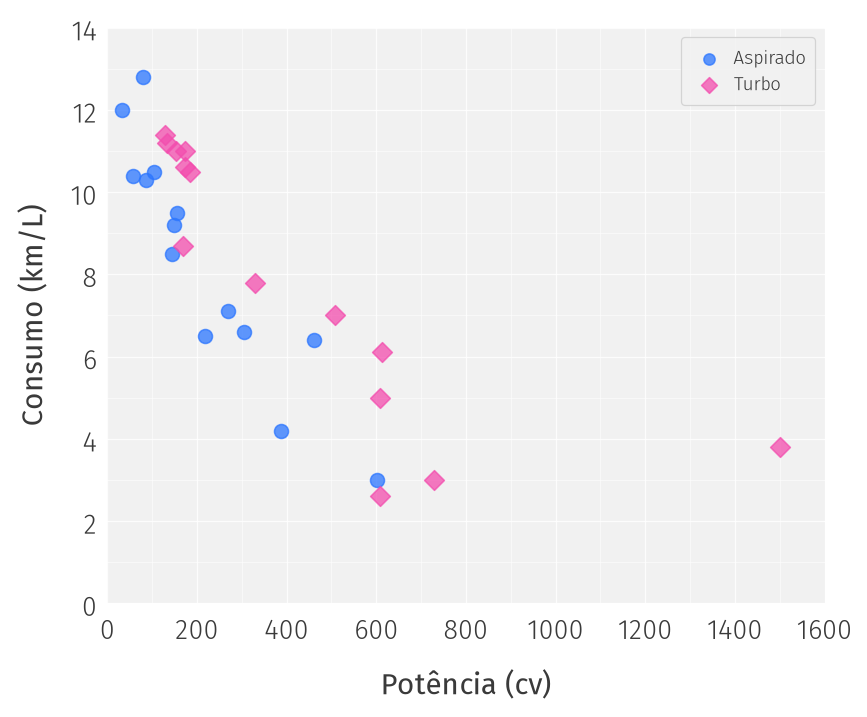

In [261]:
fig, ax = plt.subplots(figsize=(6, 5))

# ax.set_title("Potência em função do consumo")
ax.set_xlabel("Potência (cv)"); ax.set_ylabel("Consumo (km/L)")

ax.set_xlim([0, 1600]); ax.set_ylim([0, 14])
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(1))

for tipo_motor, estilo in estilos_motor.items():
    grupo = df[df["Etype"] == tipo_motor]

    ax.scatter(
        grupo["power"],
        grupo["consumo"],
        label=estilo["label"],
        color=estilo["color"],
        marker=estilo["marker"],
        s=45,
        alpha=.75,
        linewidth=.75,
        zorder=2,
    )

ax.grid(which='major', alpha=.85, color="white", lw=.6, ls="-", zorder=-2)
ax.grid(which='minor', alpha=.65, color="white", lw=.4, ls="-", zorder=-2)
ax.legend(frameon=True, loc="upper right", linewidth=0.6)

plt.tight_layout()

In [262]:
r_global = df["power"].corr(df["consumo"])

r_aspirado = (
    df.loc[df["Etype"] == 0, "power"]
      .corr(df.loc[df["Etype"] == 0, "consumo"])
)

r_turbo = (
    df.loc[df["Etype"] == 1, "power"]
      .corr(df.loc[df["Etype"] == 1, "consumo"])
)

print(f"Global: r = {r_global:.3f}")
print(f"Aspirados: r = {r_aspirado:.3f}")
print(f"Turbos: r = {r_turbo:.3f}")

Global: r = -0.777
Aspirados: r = -0.915
Turbos: r = -0.806


Observou-se uma associação linear negativa entre potência e consumo, com
r = -0,777 para o conjunto completo de veículos. Portanto, carros mais
potentes tendem a percorrer menos quilômetros por litro.

A associação tornou-se mais forte após a separação por tipo de motor:
r = -0,915 para os aspirados e r = -0,806 para os turbos. Assim, a redução
do consumo com o aumento da potência permanece presente nos dois grupos,
mas os veículos aspirados acompanham uma tendência linear mais consistente.

O coeficiente de correlação não informa, entretanto, em qual grupo o consumo
diminui mais rapidamente. Essa comparação exige o ajuste e a análise das
inclinações das retas.

### 8.2 Ajustes lineares por grupo

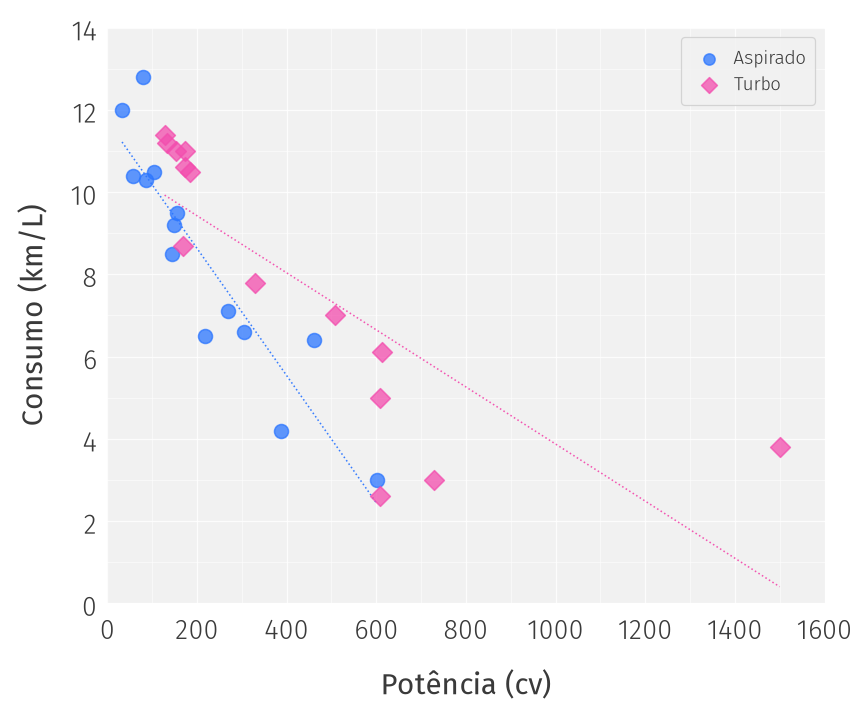

In [268]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Potência (cv)"); ax.set_ylabel("Consumo (km/L)")

ax.set_xlim([0, 1600]); ax.set_ylim([0, 14])
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(1))

resultados_consumo = {}

for tipo_motor, estilo in estilos_motor.items():
    grupo = df[df["Etype"] == tipo_motor]

    x = grupo["power"].to_numpy()
    y = grupo["consumo"].to_numpy()

    # Ajuste linear: consumo = b0 + b1 * power
    b1, b0 = np.polyfit(x, y, deg=1)

    resultados_consumo[tipo_motor] = {
        "tipo_motor": estilo["label"],
        "intercepto": b0,
        "inclinacao": b1,
        "variacao_por_100_cv": b1 * 100,
        "n": len(grupo),
    }

    ax.scatter(
        x,
        y,
        label=estilo["label"],
        color=estilo["color"],
        marker=estilo["marker"],
        s=45,
        alpha=.75,
        linewidth=.75,
        zorder=3,
    )

    x_reta = np.linspace(x.min(), x.max(), 100)
    y_reta = b0 + b1 * x_reta

    ax.plot(
        x_reta,
        y_reta,
        color=estilo["color"],
        lw=.75,
        ls=":",
        alpha=.95,
        zorder=2,
    )

ax.grid(which='major', alpha=.85, color="white", lw=.6, ls="-", zorder=-2)
ax.grid(which='minor', alpha=.65, color="white", lw=.4, ls="-", zorder=-2)
ax.legend(frameon=True, loc="upper right", linewidth=0.6)

plt.tight_layout()

In [269]:
ajustes_consumo = (
    pd.DataFrame(resultados_consumo)
    .T
    .set_index("tipo_motor")
)

ajustes_consumo.index.name = "Tipo de motor"

ajustes_consumo.round({
    "intercepto": 2,
    "inclinacao": 4,
    "variacao_por_100_cv": 2,
})

,intercepto,inclinacao,variacao_por_100_cv,n
Tipo de motor,,,,
Aspirado,11.72962,-0.01547,-1.547008,14
Turbo,10.815463,-0.006942,-0.694233,14


In [270]:
linhas = []

for resultado in resultados_consumo.values():
    grupo = resultado["tipo_motor"]
    b0 = resultado["intercepto"]
    b1 = resultado["inclinacao"]

    sinal = "+" if b0 >= 0 else "-"

    linhas.append(
        rf"\text{{{grupo}:}}\quad "
        rf"\widehat{{C}} = "
        rf"\left({b1:.4f}\,"
        rf"\frac{{\mathrm{{km/L}}}}{{\mathrm{{cv}}}}\right)P "
        rf"{sinal} "
        rf"{abs(b0):.2f}\,\mathrm{{km/L}}"
    )

equacoes = (
    r"\begin{aligned}"
    + r" \\[6pt] ".join(linhas)
    + r"\end{aligned}"
)

display(Math(equacoes))

display(Math(
    r"[P]=\mathrm{cv},"
    r"\qquad"
    r"[\widehat{C}]=\mathrm{km/L}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

O consumo apresentou relação linear negativa com a potência em ambos os tipos
de motor. Entre os aspirados, estima-se uma redução média de 1,55 km/L para
cada aumento de 100 cv, enquanto entre os turbos a redução estimada é de
0,69 km/L por 100 cv.

Assim, a reta dos aspirados apresenta inclinação mais negativa. Entretanto,
o veículo turbo de maior potência pode influenciar o ajuste desse grupo,
tornando necessária uma análise de sensibilidade antes da interpretação final.

### 8.3 Análise de sensibilidade do turbo extremo

In [271]:
# Mesmo veículo extremo usado anteriormente:
# turbo com a maior potência
indice_extremo_turbo = (
    df.loc[df["Etype"] == 1, "power"]
      .idxmax()
)

grupo_turbo = df[df["Etype"] == 1]
grupo_turbo_sem_extremo = grupo_turbo.drop(
    index=indice_extremo_turbo
)

# Ajuste com todos os turbos
b1_original, b0_original = np.polyfit(
    grupo_turbo["power"],
    grupo_turbo["consumo"],
    deg=1,
)

# Ajuste sem o turbo extremo
b1_sem, b0_sem = np.polyfit(
    grupo_turbo_sem_extremo["power"],
    grupo_turbo_sem_extremo["consumo"],
    deg=1,
)

r_original = grupo_turbo["power"].corr(
    grupo_turbo["consumo"]
)

r_sem = grupo_turbo_sem_extremo["power"].corr(
    grupo_turbo_sem_extremo["consumo"]
)

comparacao_consumo_turbo = pd.DataFrame({
    "Ajuste": [
        "Todos os turbos",
        "Sem o ponto extremo",
    ],
    "Inclinação [(km/L)/cv]": [
        b1_original,
        b1_sem,
    ],
    "Variação por 100 cv (km/L)": [
        100 * b1_original,
        100 * b1_sem,
    ],
    "Intercepto (km/L)": [
        b0_original,
        b0_sem,
    ],
    "Correlação r": [
        r_original,
        r_sem,
    ],
    "n": [
        len(grupo_turbo),
        len(grupo_turbo_sem_extremo),
    ],
})

comparacao_consumo_turbo.round({
    "Inclinação [(km/L)/cv]": 5,
    "Variação por 100 cv (km/L)": 2,
    "Intercepto (km/L)": 2,
    "Correlação r": 3,
})

,Ajuste,Inclinação [(km/L)/cv],Variação por 100 cv (km/L),Intercepto (km/L),Correlação r,n
0,Todos os turbos,-0.00694,-0.69,10.82,-0.806,14
1,Sem o ponto extremo,-0.01317,-1.32,12.72,-0.950,13


O veículo turbo de maior potência apresentou influência relevante sobre o ajuste.
Com sua inclusão, estima-se uma redução de 0,69 km/L para cada aumento de 100 cv.
Após sua retirada, essa redução passa para 1,32 km/L por 100 cv, e a correlação
se intensifica de $r = -0,806$ para $r = -0{,}950$.

Assim, o ponto influente suavizava a inclinação negativa da reta dos turbos.
Sem ele, a relação entre potência e consumo torna-se muito semelhante à observada
nos aspirados, cuja redução estimada é de 1,55 km/L por 100 cv. Portanto, a grande
diferença inicial entre as inclinações não parece representar uma característica
geral dos dois tipos de motor, mas depende fortemente desse veículo turbo.

## 9. Síntese parcial

- A capacidade volumétrica apresenta associação linear positiva forte com a potência nos dois tipos de motor.
- Mesmo após a análise de sensibilidade, os turbos mantêm maior ganho estimado de potência por unidade de cilindrada.
- O consumo apresenta associação linear negativa com a potência em ambos os grupos.
- Na relação entre potência e consumo, a diferença inicial entre as inclinações depende fortemente do veículo turbo extremo.

O ponto extremo foi mantido nos resultados principais e avaliado separadamente por análises de sensibilidade.